MSE : 0.0759354671321544
RMSE: 0.27556390752809845
R2 Score: 0.04745846722337177


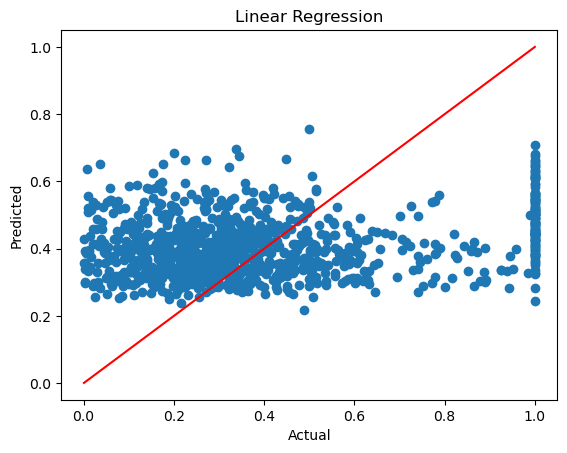

In [19]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
import matplotlib.pyplot as plt

#Load dataset
df = pd.read_csv(r"C:\Users\R5b\Downloads\archive\stroke_preprocessed.csv")


# Convert boolean columns
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Remove ID-id is only an identifier.It has no relationship with glucose level.Keeping it can introduce noise into the model
df = df.drop("id", axis=1)

# Handle missing categorical values
df["age_group"] = df["age_group"].fillna("Unknown")
df["bmi_category"] = df["bmi_category"].fillna("Unknown")

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

# X-Feature(contain all columns except target)
# y-Target Variable(model try to predict avg_gluose_level)
X = df.drop("avg_glucose_level", axis=1)
y = df["avg_glucose_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression() #Create empty linear regtression model(Model existsbut has learned nothing)


#=======================================================
#Learning step
#Model find coefficients and intercept
#glucose=b0+b1(age)+b2(bmi).....
#======================================================
model.fit(X_train, y_train)


# Predict(Uses the trained model to predict glucose levels for unseen test data.)
y_pred = model.predict(X_test)


#===========================================================
#MSE-average squared error between actual and predicted value
#R2 score-how much variation in target explainerd y model
    #R2=1 perfect prediction
    #R2=0.7 good prediction
    #R2<0 poor model
#===========================================================

print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))



#===========================================================
#The line represents:Prediction = Actual
#Good model:Points close to red line
#Poor model:Points far away from red line
#===========================================================
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()